# 🎓 Student Placement Predictor

## End-to-End Machine Learning Project

This notebook demonstrates the complete machine learning workflow for predicting whether a student is likely to be placed based on academic performance, technical skills, internships, projects, and extracurricular activities.

### 📚 Import Libraries and Load Dataset

In [2]:
import pandas as pd

df = pd.read_csv("student_placement_prediction_dataset_2026.csv")  
df.shape

(100000, 26)

In [3]:
df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


### 🔍 Data Quality Check

In [4]:
print(df.isnull().sum())

student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64


### 📊 Target Variable Distribution

In [5]:
df["placement_status"].value_counts()

placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64

###  Data Leakage Detection

In [6]:
df.groupby("placement_status")["salary_package_lpa"].describe()

,count,mean,std,min,25%,50%,75%,max
placement_status,,,,,,,,
Not Placed,45541.0,0.000000,0.000000,0.00,0.00,0.0,0.00,0.00
Placed,54459.0,13.316635,1.592418,7.11,12.23,13.3,14.39,20.44


### 🧹 Data Cleaning

In [7]:
drop_cols = ["student_id", "salary_package_lpa", "placement_status"]

numeric_features = [
    "age", "cgpa", "internships_count", "projects_count", "certifications_count",
    "coding_skill_score", "aptitude_score", "communication_skill_score",
    "logical_reasoning_score", "hackathons_participated", "github_repos",
    "linkedin_connections", "mock_interview_score", "attendance_percentage",
    "backlogs", "extracurricular_score", "leadership_score",
    "sleep_hours", "study_hours_per_day"
]

categorical_features = ["gender", "branch", "college_tier", "volunteer_experience"]

X = df[numeric_features + categorical_features]
y = (df["placement_status"] == "Placed").astype(int)  # 1 = Placed, 0 = Not Placed

X.shape, y.shape

((100000, 23), (100000,))

In [8]:
df["placed"] = (df["placement_status"] == "Placed").astype(int)
corr = df[numeric_features + ["placed"]].corr()["placed"].sort_values()
print(corr)

backlogs                    -0.082404
attendance_percentage       -0.008350
sleep_hours                 -0.004692
certifications_count        -0.003806
study_hours_per_day         -0.001426
age                          0.000858
hackathons_participated      0.001236
linkedin_connections         0.003223
github_repos                 0.004807
cgpa                         0.012067
extracurricular_score        0.020100
leadership_score             0.022170
aptitude_score               0.031690
communication_skill_score    0.032242
logical_reasoning_score      0.036332
mock_interview_score         0.046058
coding_skill_score           0.050773
projects_count               0.060964
internships_count            0.063489
placed                       1.000000
Name: placed, dtype: float64


### ✂️ Train-Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 80000
Test size: 20000


### ⚙️ Data Preprocessing

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

### 🤖 Model Selection

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc")
    print(f"{name}: mean ROC-AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")

LogisticRegression: mean ROC-AUC = 0.5851 (+/- 0.0039)
RandomForest: mean ROC-AUC = 0.5804 (+/- 0.0028)


### 🔄 Model Training and Cross Validation

In [12]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

final_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 📊 Model Evaluation

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

preds = final_pipeline.predict(X_test)
probs = final_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1:", f1_score(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, preds))

Accuracy: 0.57005
Precision: 0.5788894240693594
Recall: 0.77240176276166
F1: 0.6617895771878073
ROC-AUC: 0.5849299066927882

Confusion Matrix:
 [[2988 6120]
 [2479 8413]]


### 💾 Save the Trained Model

In [14]:
import joblib

joblib.dump(final_pipeline, "placement_classifier.pkl")
print("Model saved as placement_classifier.pkl")

Model saved as placement_classifier.pkl


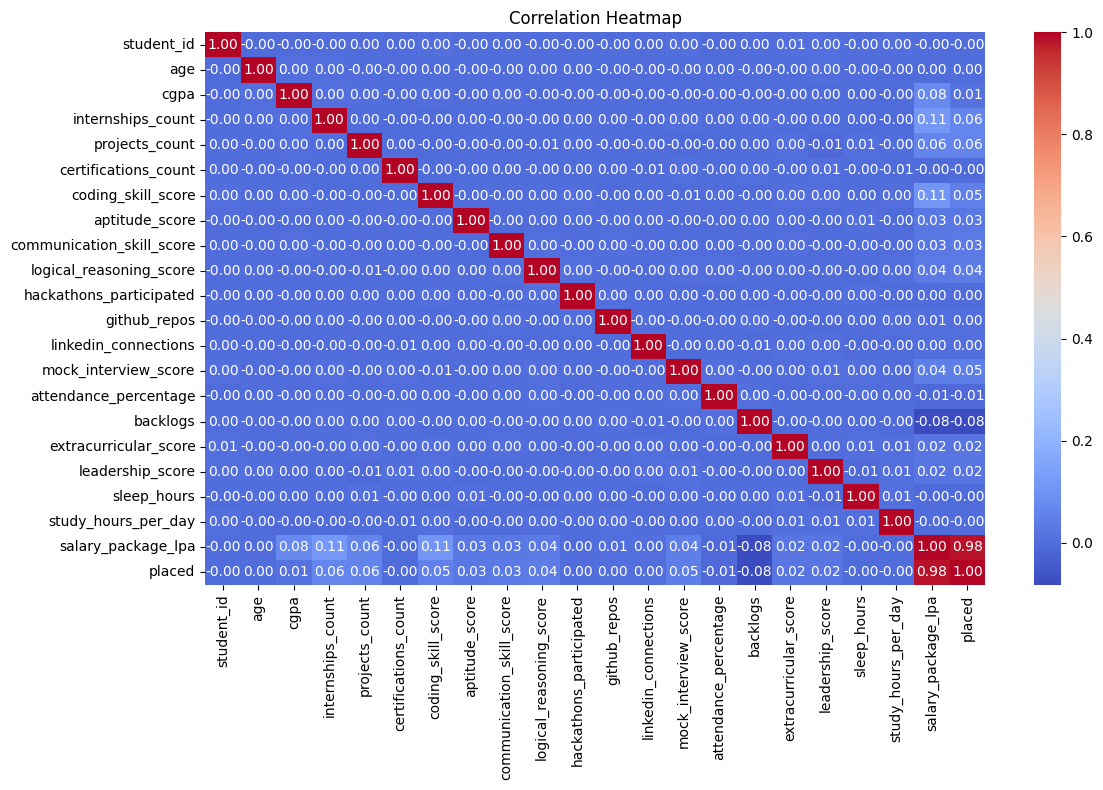

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()